In [87]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
    
import scipy.stats as stats

In [88]:
from sklearn.model_selection import train_test_split,cross_val_score 

In [89]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PowerTransformer
from sklearn.metrics import r2_score


In [90]:
df=pd.read_csv('./CSVs/concrete_data.csv')

In [91]:
df.sample(5)

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
847,280.0,129.0,100.0,172.0,9.0,825.0,805.0,28,52.82
551,255.0,0.0,0.0,192.0,0.0,889.8,945.0,3,8.20
281,251.4,0.0,118.3,188.5,6.4,1028.4,757.7,28,32.66
69,485.0,0.0,0.0,146.0,0.0,1120.0,800.0,28,71.99
854,287.0,121.0,94.0,188.0,9.0,904.0,696.0,28,41.94


In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cement              1030 non-null   float64
 1   Blast Furnace Slag  1030 non-null   float64
 2   Fly Ash             1030 non-null   float64
 3   Water               1030 non-null   float64
 4   Superplasticizer    1030 non-null   float64
 5   Coarse Aggregate    1030 non-null   float64
 6   Fine Aggregate      1030 non-null   float64
 7   Age                 1030 non-null   int64  
 8   Strength            1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [93]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [94]:
X=df.drop('Strength',axis=1)

In [95]:
Y=df.Strength

In [24]:
LR=LinearRegression()

In [97]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.15)

In [26]:
LR.fit(X_train,Y_train)

LinearRegression()

In [27]:
pred=LR.predict(X_test)

In [28]:
r2_score(Y_test,pred)

0.6184508723846357

In [29]:
lr=LinearRegression()

In [31]:
np.mean(cross_val_score(lr,X,Y,scoring='r2'))

0.46099404916628633

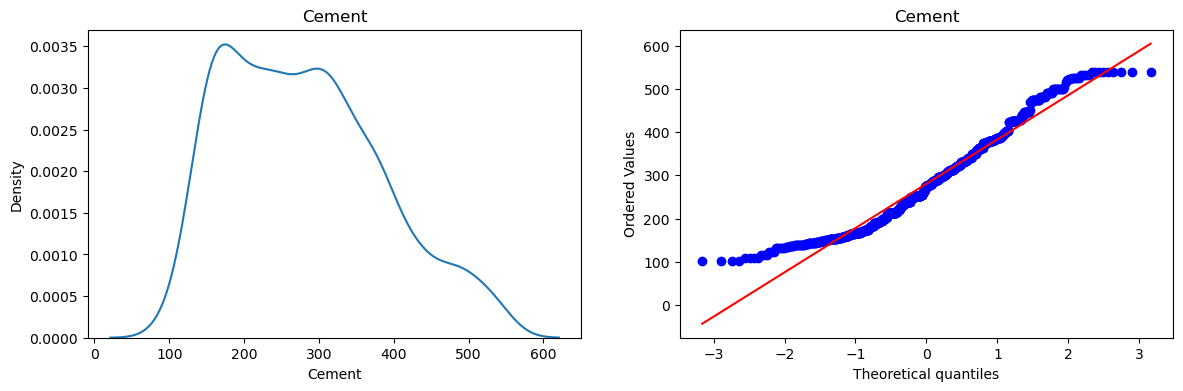

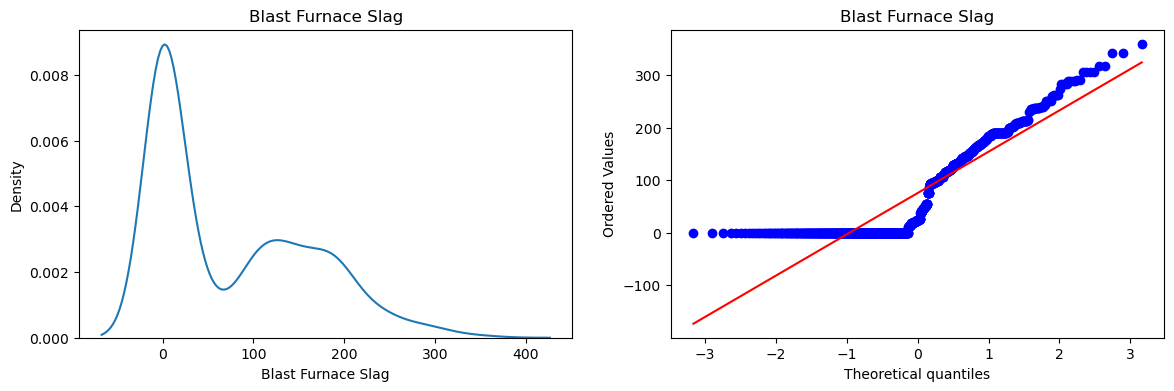

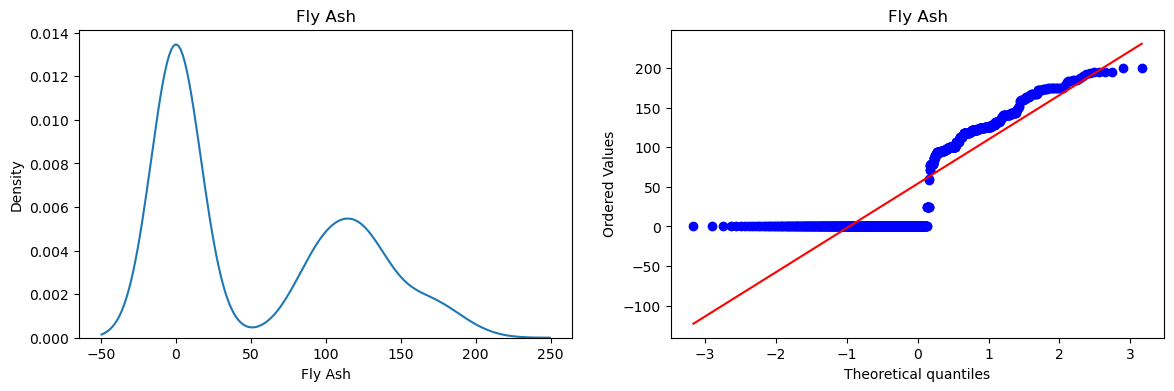

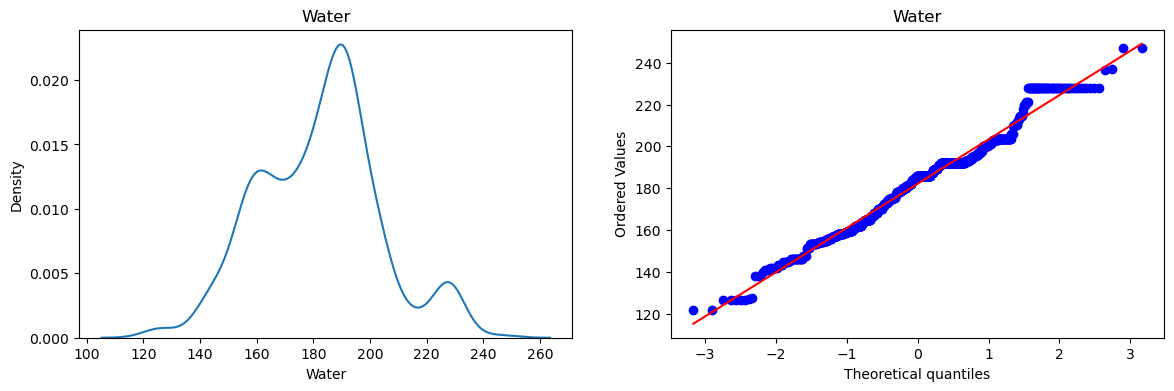

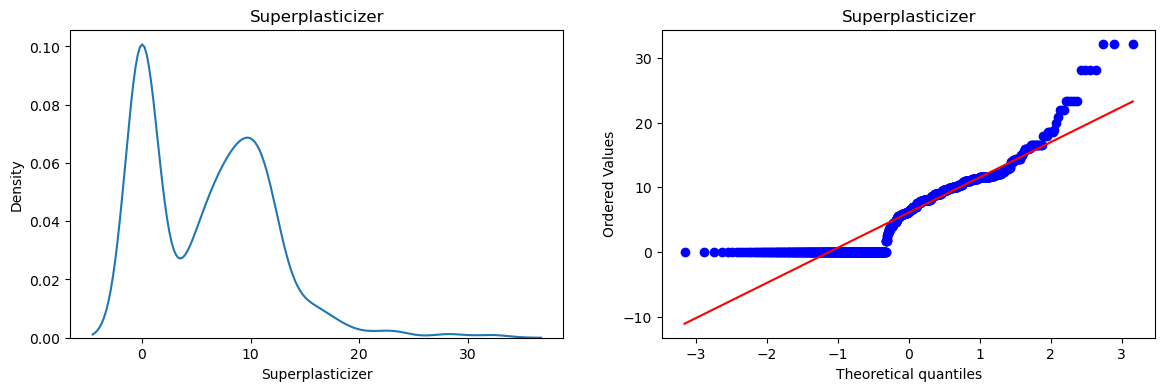

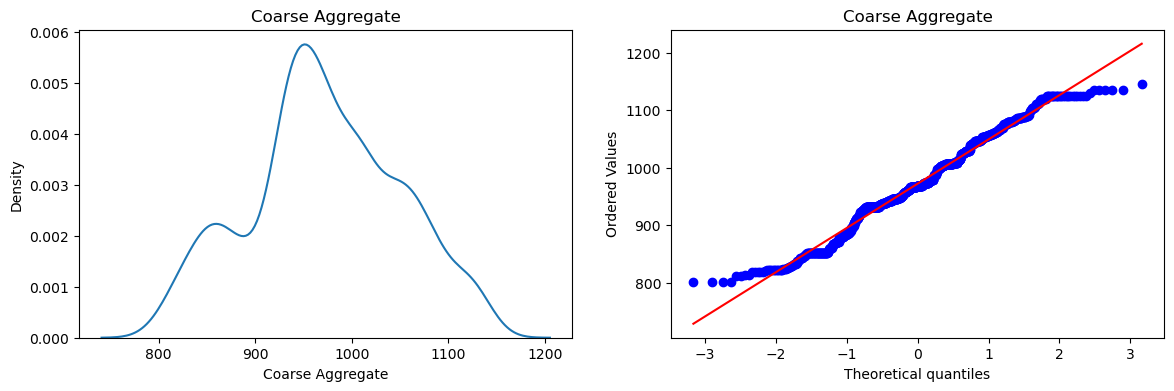

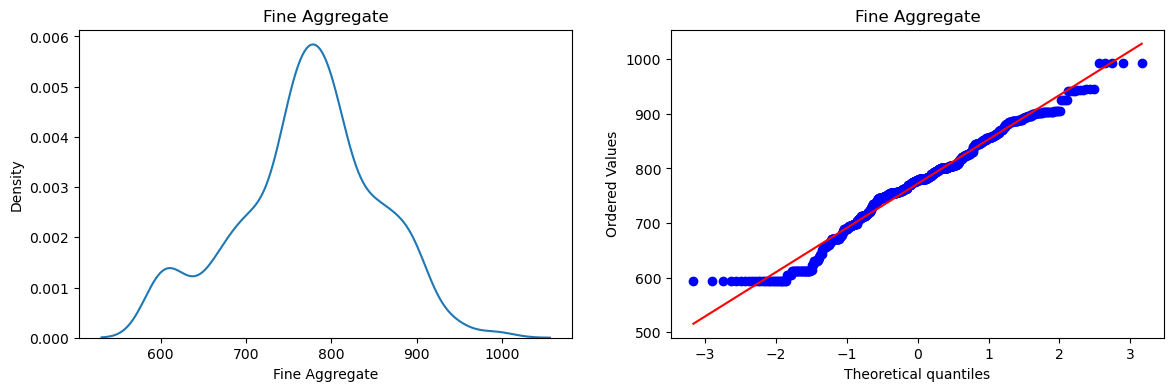

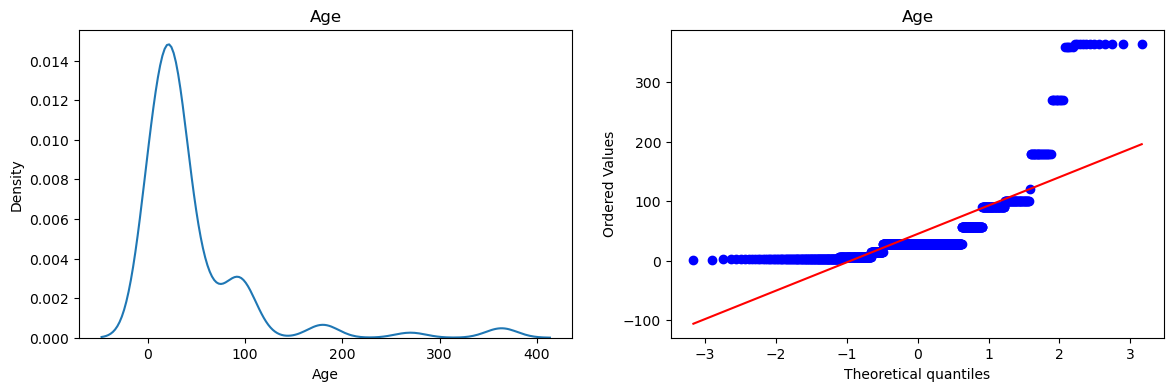

In [46]:
for col in X_train.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(1,2,1)
    sns.kdeplot(X_train[col])
    plt.title(col)

    plt.subplot(122)
    stats.probplot(X_train[col],dist='norm',plot=plt)
    plt.title(col)

    plt.show()

In [84]:
pt=PowerTransformer(method='box-cox')

x_train_box_cox=pt.fit_transform(X_train+0.000001)
x_test_box_cox=pt.transform(X_test+0.000001)
X_bc=pt.fit_transform(X+0.000001)

pd.DataFrame({'cols':X_train.columns,'lambas':pt.lambdas_})


,cols,lambas
0,Cement,0.172271
1,Blast Furnace Slag,0.025273
2,Fly Ash,-0.032412
3,Water,0.809568
4,Superplasticizer,0.099711
5,Coarse Aggregate,1.129168
6,Fine Aggregate,1.829625
7,Age,0.048975


In [70]:
type(x_train_box_cox)

numpy.ndarray

In [76]:
x_train_box_cox=pd.DataFrame(x_train_box_cox,columns=X_train.columns)

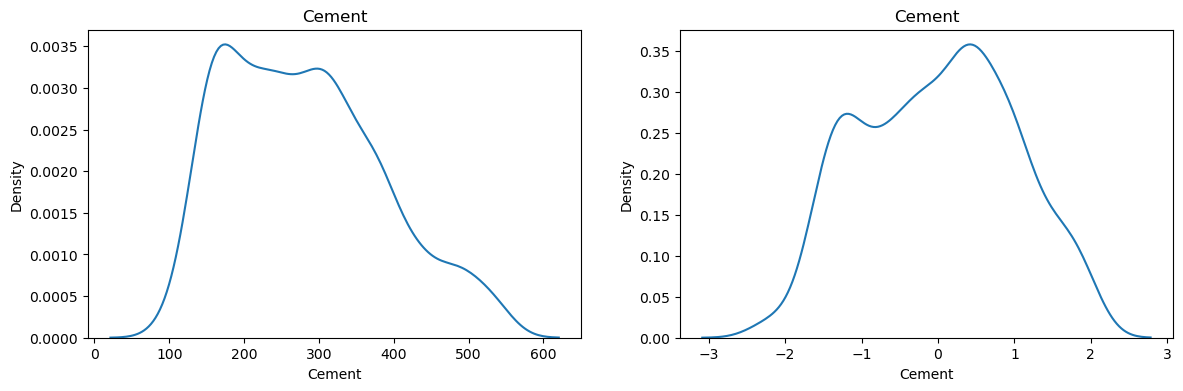

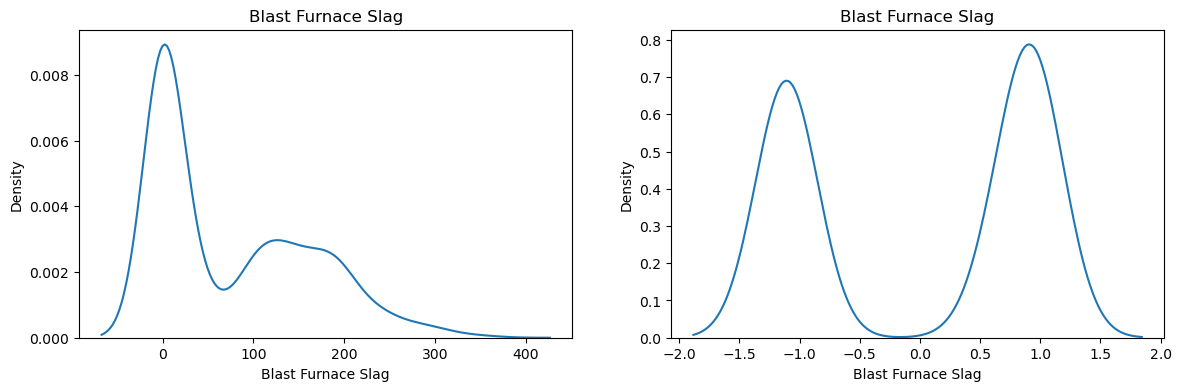

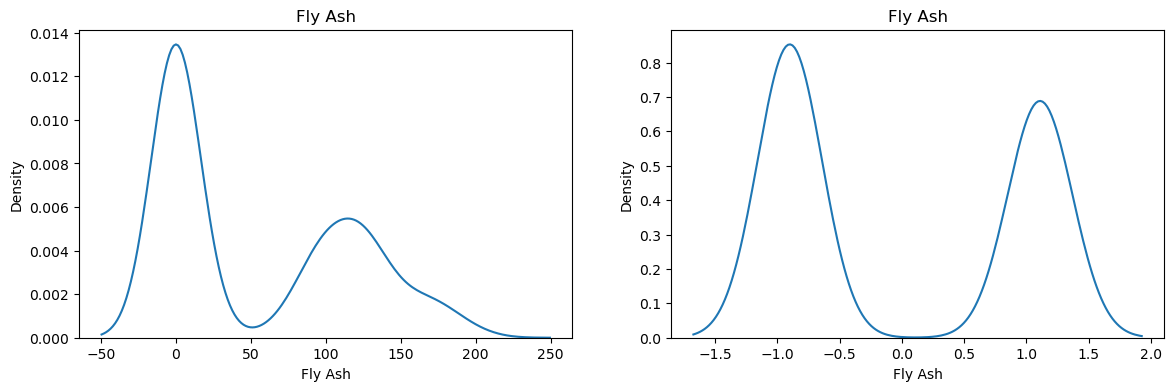

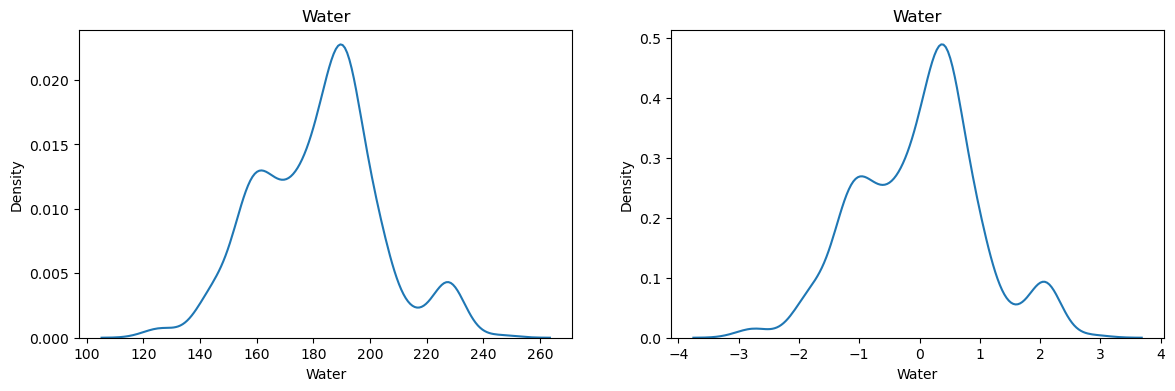

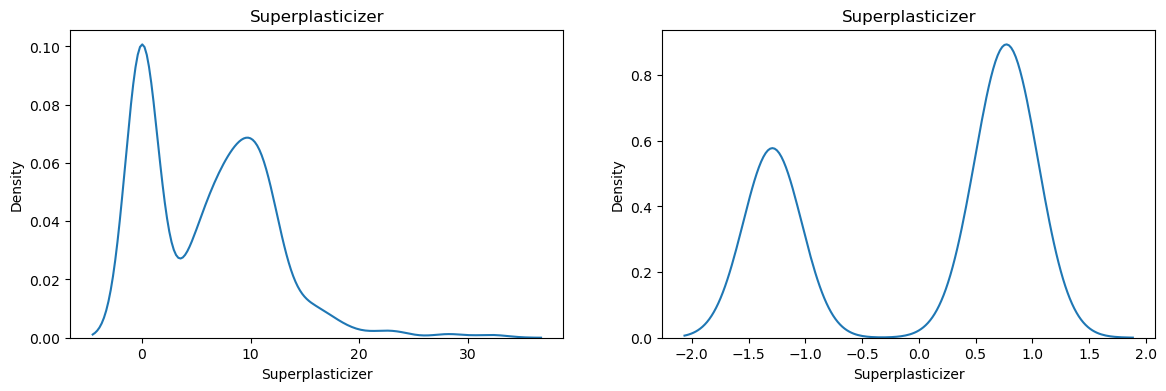

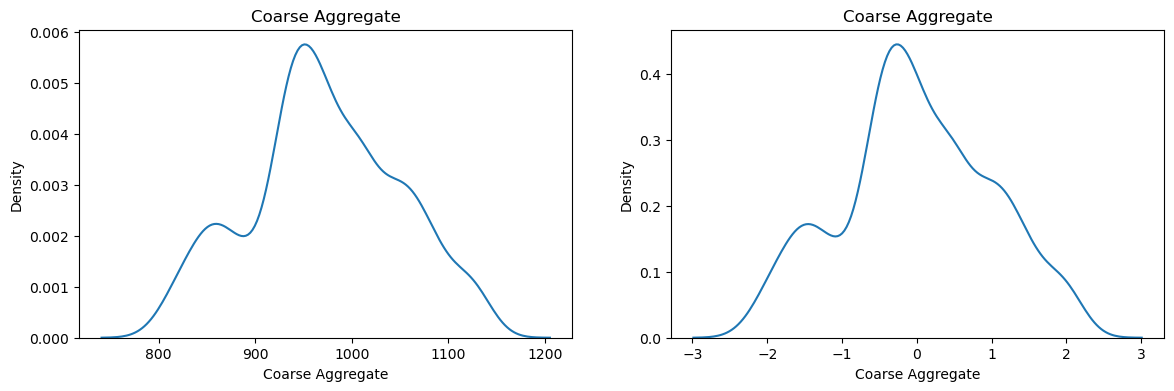

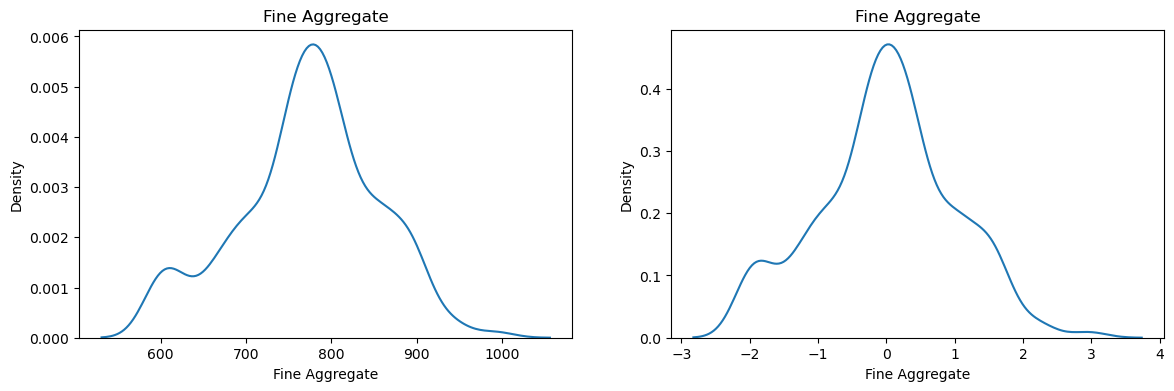

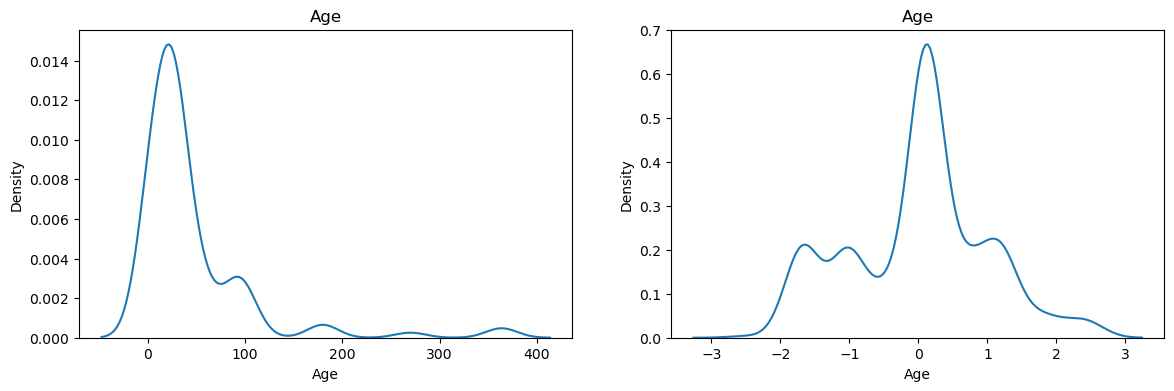

In [77]:
for col in x_train_box_cox.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(1,2,1)
    sns.kdeplot(X_train[col])
    plt.title(col)

    plt.subplot(1,2,2)
    sns.kdeplot(x_train_box_cox[col])
    plt.title(col)

    plt.show()

In [78]:
lrbc=LinearRegression()

In [80]:
lrbc.fit(x_train_box_cox,Y_train)

LinearRegression()

In [82]:
pred=lrbc.predict(x_test_box_cox)

C:\Users\Admi\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [83]:
r2_score(Y_test,pred)

0.8066873638075243

In [86]:
np.mean(cross_val_score(lrbc,X_bc,Y,scoring='r2'))

0.6662950324463969

In [96]:
pt=PowerTransformer()

In [98]:
x_train_yeo=pt.fit_transform(X_train)
x_test_yeo=pt.transform(X_test)

In [99]:
lryj=LinearRegression()

In [102]:
x_train_yeo=pd.DataFrame(data=x_train_yeo,columns=X_train.columns)

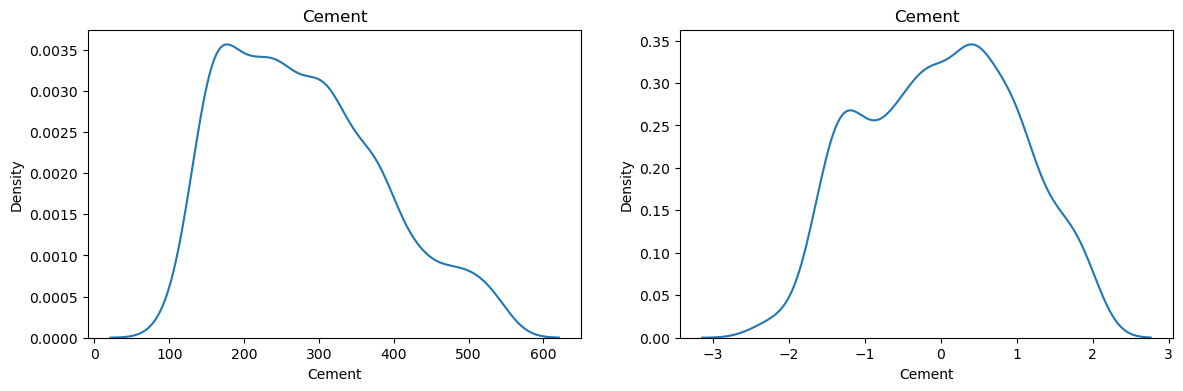

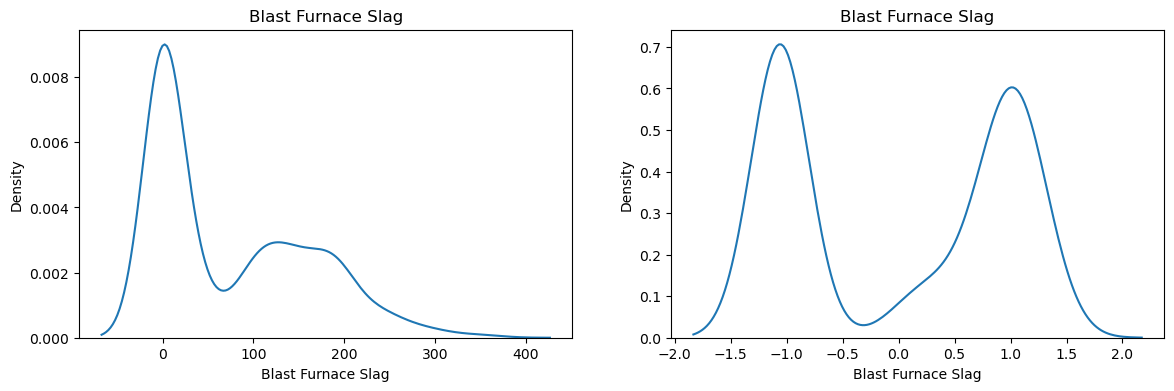

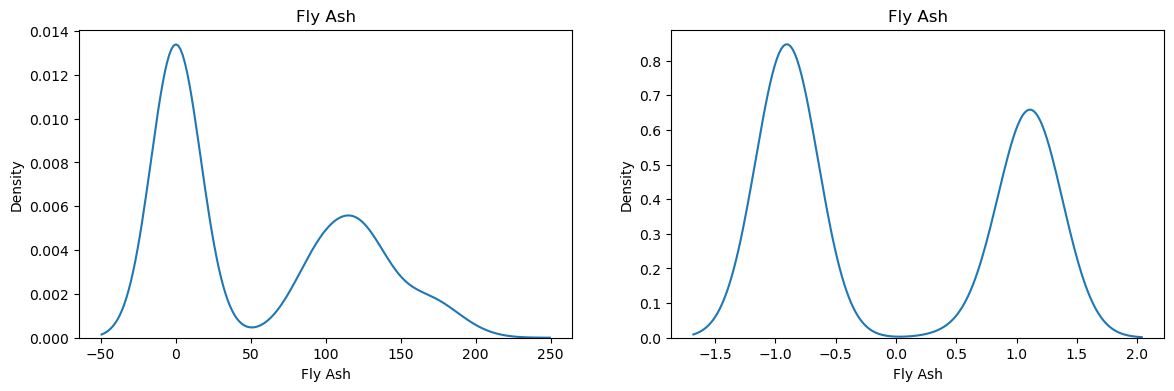

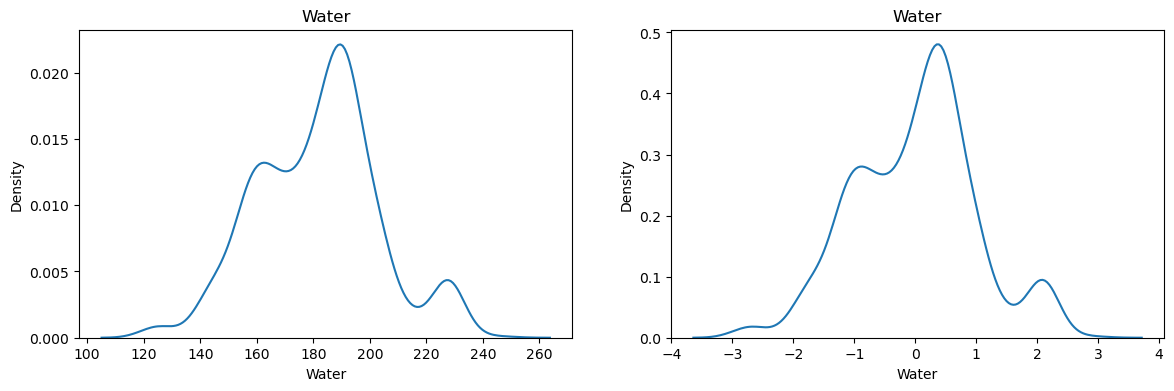

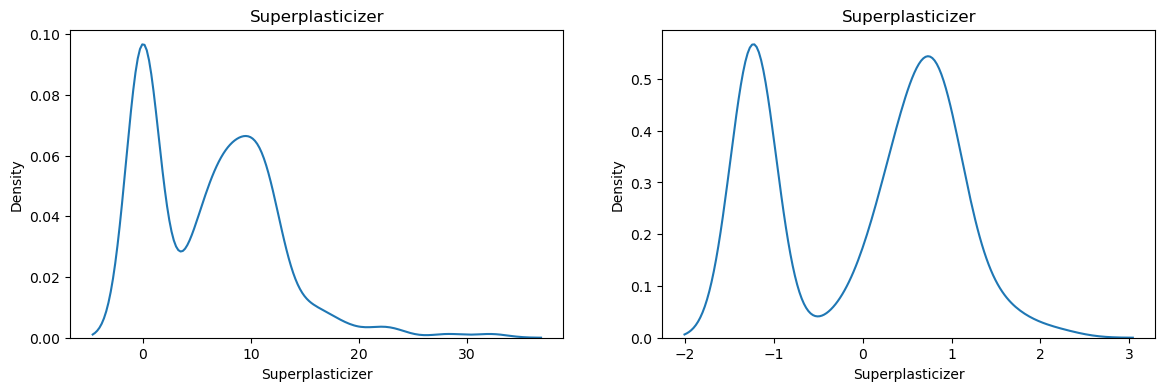

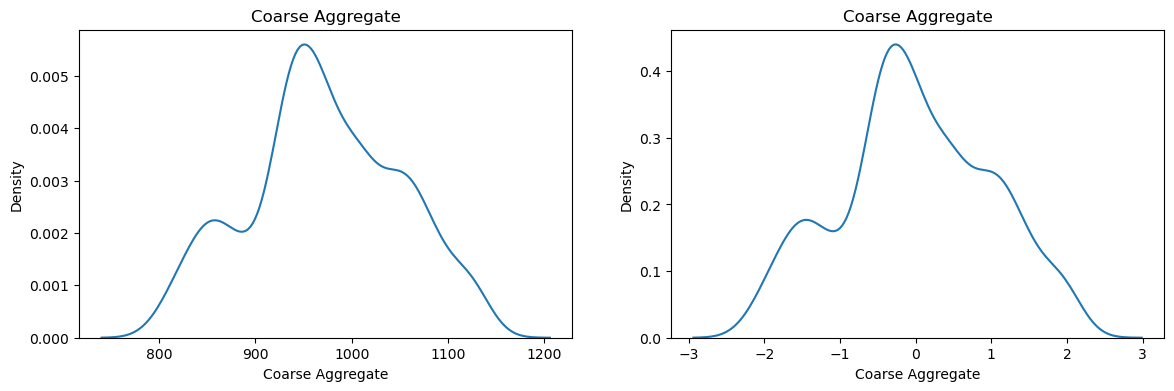

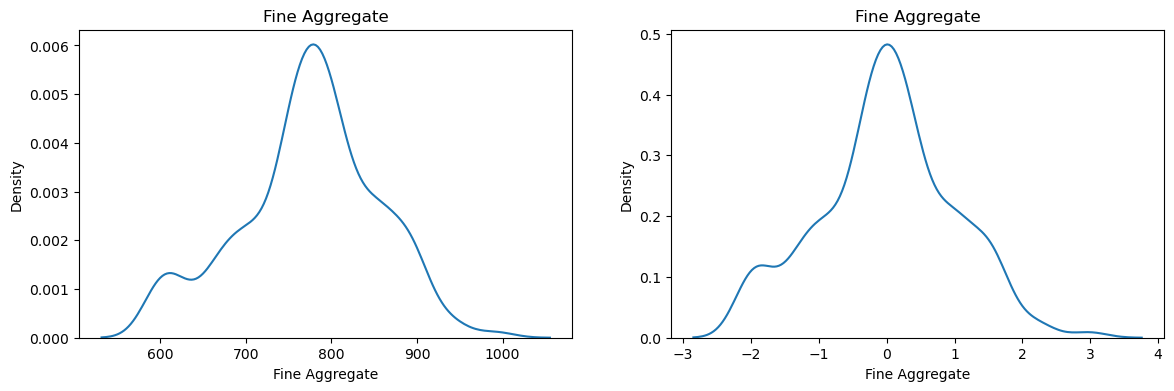

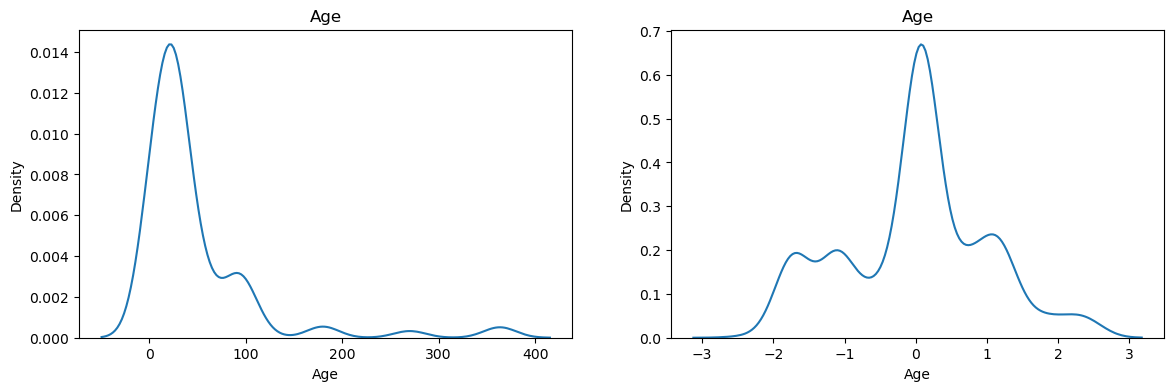

In [104]:
for col in x_train_yeo.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(1,2,1)
    sns.kdeplot(X_train[col])
    plt.title(col)

    plt.subplot(1,2,2)
    sns.kdeplot(x_train_yeo[col])
    plt.title(col)

    plt.show()

In [105]:
lryj.fit(x_train_yeo,Y_train)

LinearRegression()

In [106]:
pred=lryj.predict(x_test_yeo)

C:\Users\Admi\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [107]:
r2_score(Y_test,pred)

0.8110768632876051

In [108]:
np.mean(cross_val_score(lryj,X_bc,Y,scoring='r2'))

0.6662950324463969